In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [4]:
df = pd.read_pickle(os.path.join(path, 'Dataset-long_unscaled.pkl'))

In [5]:
pleasant = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [6]:
df.columns.name = None

In [7]:
# Convert from wide format to long format using melt
ans_long = pleasant.melt(id_vars=['DATE'], 
                 var_name='city_metric', 
                 value_name='value')

In [8]:
# Split city name from variables
split_values = ans_long['city_metric'].str.split('_', n=1, expand=True)
ans_long['city'] = split_values[0]
ans_long['metric'] = split_values[1]
# Pivot into new columns
ans_long = ans_long.drop('city_metric', axis=1).pivot_table(
   index=['DATE', 'city'], 
   columns='metric', 
   values='value', 
   aggfunc='first'
).reset_index()

In [9]:
ans_long['DATE'] = pd.to_datetime(ans_long['DATE'], format='%Y%m%d')

In [9]:
# Check missing data patterns by city
missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())
print("Missing values by city:")
print(missing_by_city)

Missing values by city:
            DATE  MONTH  city  cloud_cover  global_radiation  humidity  \
city                                                                     
BASEL          0      0     0            0                 0         0   
BELGRADE       0      0     0            0                 0         0   
BUDAPEST       0      0     0            0                 0         0   
DEBILT         0      0     0            0                 0         0   
DUSSELDORF     0      0     0            0                 0         0   
GDANSK         0      0     0            0             22950         0   
HEATHROW       0      0     0            0                 0         0   
KASSEL         0      0     0        22950                 0         0   
LJUBLJANA      0      0     0            0                 0         0   
MAASTRICHT     0      0     0            0                 0         0   
MADRID         0      0     0            0                 0         0   
MUNCHENB      

/tmp/ipykernel_37377/2497628529.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())


In [10]:
df = df.drop(columns=['snow_depth', 'wind_speed'])

In [11]:
# Check missing data patterns by city
missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())
print("Missing values by city:")
print(missing_by_city)

Missing values by city:
            DATE  MONTH  city  cloud_cover  global_radiation  humidity  \
city                                                                     
BASEL          0      0     0            0                 0         0   
BELGRADE       0      0     0            0                 0         0   
BUDAPEST       0      0     0            0                 0         0   
DEBILT         0      0     0            0                 0         0   
DUSSELDORF     0      0     0            0                 0         0   
GDANSK         0      0     0            0             22950         0   
HEATHROW       0      0     0            0                 0         0   
KASSEL         0      0     0        22950                 0         0   
LJUBLJANA      0      0     0            0                 0         0   
MAASTRICHT     0      0     0            0                 0         0   
MADRID         0      0     0            0                 0         0   
MUNCHENB      

/tmp/ipykernel_21393/2497628529.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())


In [11]:
climate = df[~df['city'].isin(['GDANSK','ROMA','TOURS'])].copy()

In [13]:
# Check missing data patterns by city
missing_by_city = climate.groupby('city').apply(lambda x: x.isnull().sum())
print("Missing values by city:")
print(missing_by_city)

Missing values by city:
            DATE  MONTH  city  cloud_cover  global_radiation  humidity  \
city                                                                     
BASEL          0      0     0            0                 0         0   
BELGRADE       0      0     0            0                 0         0   
BUDAPEST       0      0     0            0                 0         0   
DEBILT         0      0     0            0                 0         0   
DUSSELDORF     0      0     0            0                 0         0   
HEATHROW       0      0     0            0                 0         0   
KASSEL         0      0     0        22950                 0         0   
LJUBLJANA      0      0     0            0                 0         0   
MAASTRICHT     0      0     0            0                 0         0   
MADRID         0      0     0            0                 0         0   
MUNCHENB       0      0     0            0                 0         0   
OSLO          

/tmp/ipykernel_21393/3035879728.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_city = climate.groupby('city').apply(lambda x: x.isnull().sum())


In [12]:
oslo_humidity = climate[climate['city'] == 'OSLO'].set_index('DATE')['humidity']
climate.loc[climate['city'] == 'STOCKHOLM', 'humidity'] = climate.loc[climate['city'] == 'STOCKHOLM', 'DATE'].map(oslo_humidity)

In [13]:
dussel_cloud = climate[climate['city'] == 'DUSSELDORF'].set_index('DATE')['cloud_cover']
climate.loc[climate['city'] == 'KASSEL', 'cloud_cover'] = climate.loc[climate['city'] == 'KASSEL', 'DATE'].map(dussel_cloud)

In [14]:
ljub_press = climate[climate['city'] == 'LJUBLJANA'].set_index('DATE')['pressure']
climate.loc[climate['city'] == 'MUNCHENB', 'pressure'] = climate.loc[climate['city'] == 'MUNCHENB', 'DATE'].map(ljub_press)

In [15]:
climate = climate.copy()

In [16]:
# Check missing data patterns by city
missing_by_city = climate.groupby('city').apply(lambda x: x.isnull().sum())
print("Missing values by city:")
print(missing_by_city)

Missing values by city:
            DATE  MONTH  city  cloud_cover  global_radiation  humidity  \
city                                                                     
BASEL          0      0     0            0                 0         0   
BELGRADE       0      0     0            0                 0         0   
BUDAPEST       0      0     0            0                 0         0   
DEBILT         0      0     0            0                 0         0   
DUSSELDORF     0      0     0            0                 0         0   
HEATHROW       0      0     0            0                 0         0   
KASSEL         0      0     0            0                 0         0   
LJUBLJANA      0      0     0            0                 0         0   
MAASTRICHT     0      0     0            0                 0         0   
MADRID         0      0     0            0                 0         0   
MUNCHENB       0      0     0            0                 0         0   
OSLO          

/tmp/ipykernel_37377/3035879728.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_city = climate.groupby('city').apply(lambda x: x.isnull().sum())


In [16]:
climate = climate.reset_index(drop=True).copy()
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344250 entries, 0 to 344249
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              344250 non-null  datetime64[ns]
 1   MONTH             344250 non-null  int64         
 2   city              344250 non-null  object        
 3   cloud_cover       344250 non-null  float64       
 4   global_radiation  344250 non-null  float64       
 5   humidity          344250 non-null  float64       
 6   precipitation     344250 non-null  float64       
 7   pressure          344250 non-null  float64       
 8   sunshine          344250 non-null  float64       
 9   temp_max          344250 non-null  float64       
 10  temp_mean         344250 non-null  float64       
 11  temp_min          344250 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1), object(1)
memory usage: 31.5+ MB


In [17]:
ans_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344250 entries, 0 to 344249
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              344250 non-null  datetime64[ns]
 1   city              344250 non-null  object        
 2   pleasant_weather  344250 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 7.9+ MB


In [18]:
merged = climate.merge(ans_long, on=['DATE','city'])
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344250 entries, 0 to 344249
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              344250 non-null  datetime64[ns]
 1   MONTH             344250 non-null  int64         
 2   city              344250 non-null  object        
 3   cloud_cover       344250 non-null  float64       
 4   global_radiation  344250 non-null  float64       
 5   humidity          344250 non-null  float64       
 6   precipitation     344250 non-null  float64       
 7   pressure          344250 non-null  float64       
 8   sunshine          344250 non-null  float64       
 9   temp_max          344250 non-null  float64       
 10  temp_mean         344250 non-null  float64       
 11  temp_min          344250 non-null  float64       
 12  pleasant_weather  344250 non-null  int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memor

In [55]:
feb20 = climate_df[(climate_df['DATE'].dt.year==2020) & (climate_df['MONTH']==2)]

In [28]:
noughts = climate[(climate['DATE'].dt.year>2010) & (climate['DATE'].dt.year<=2020)]

In [56]:
df_1989 = merged[(merged['DATE'].dt.year==1989)].reset_index(drop=True)

In [20]:
noughts.head()

,DATE,MONTH,city,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min
279420,2011-01-01,1,BASEL,8.0,0.13,0.97,0.00,1.0232,0.0,0.3,-0.2,-0.8
279421,2011-01-01,1,BELGRADE,4.0,0.64,0.92,0.00,1.0227,3.1,-2.3,-5.5,-8.6
279422,2011-01-01,1,BUDAPEST,4.0,0.38,0.67,0.00,1.0170,1.4,0.1,-1.7,-4.8
279423,2011-01-01,1,DEBILT,6.0,0.22,0.93,0.06,1.0211,1.2,5.9,3.5,-0.3
279424,2011-01-01,1,DUSSELDORF,6.0,0.12,0.95,0.07,1.0212,0.0,2.9,1.3,-4.1


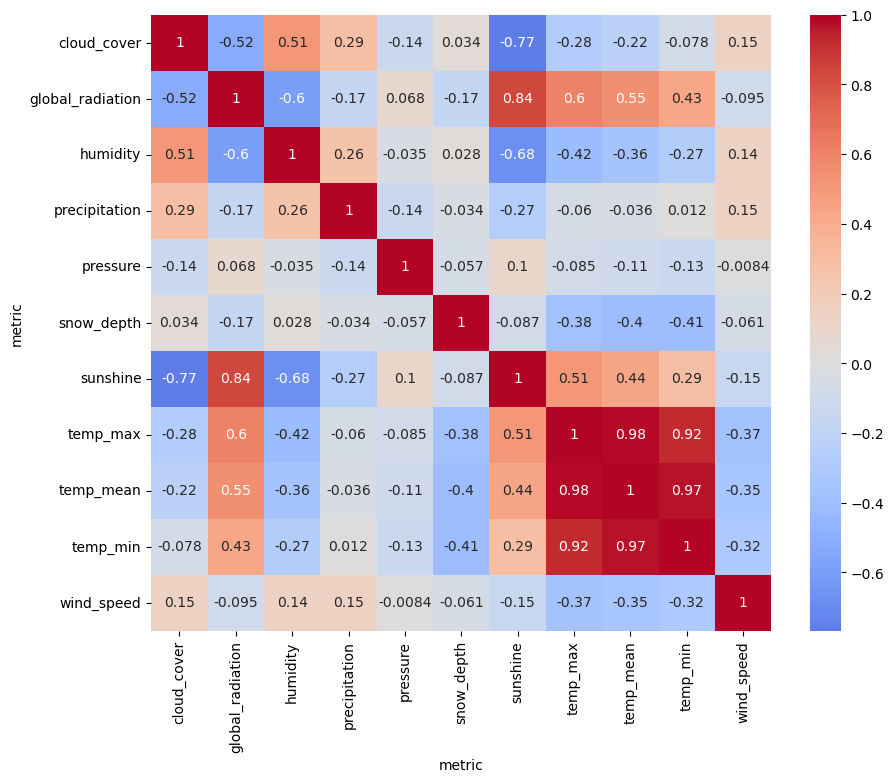

In [26]:
# Remove non-numeric and identifier columns
features_for_clustering = df_long.drop(['DATE', 'MONTH', 'city'], axis=1)

# Check for multicollinearity
correlation_matrix = features_for_clustering.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

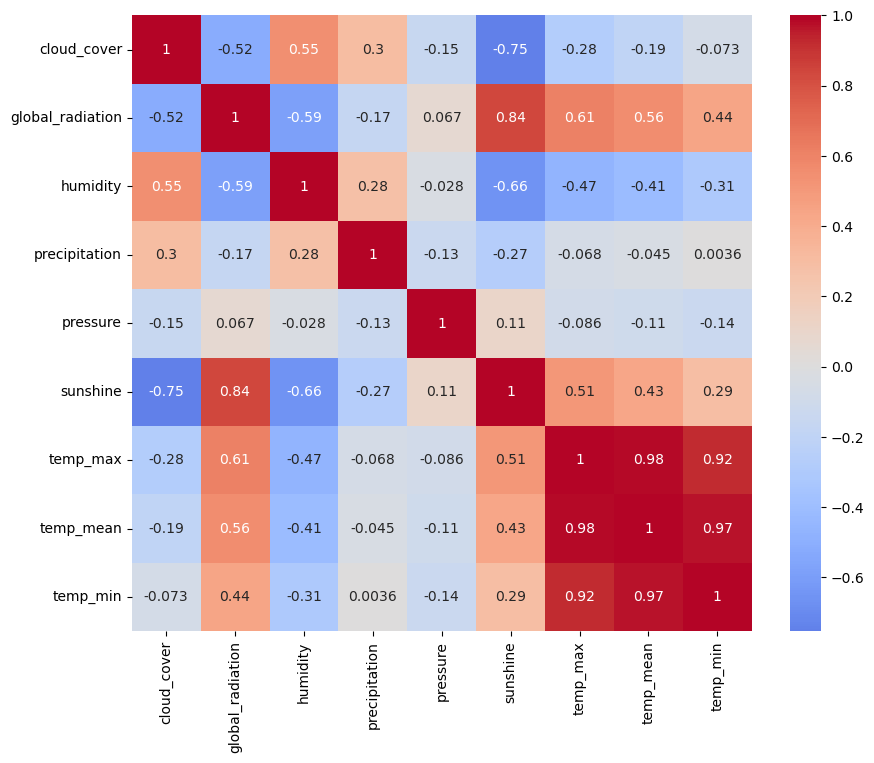

In [26]:
# Remove non-numeric and identifier columns
features_for_clustering = climate.drop(['DATE', 'MONTH', 'city'], axis=1)

# Check for multicollinearity
correlation_matrix = features_for_clustering.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

In [61]:
# Standardize features (crucial since climate variables have different scales)
scaler = StandardScaler()
id_cols = ['DATE', 'MONTH', 'city']
feature_cols = feb20.select_dtypes(include=[np.number]).columns.difference(id_cols)
features_scaled = scaler.fit_transform(feb20[feature_cols])
feb20_scaled = pd.DataFrame(features_scaled, 
                                   columns=feature_cols, 
                                   index=pd.MultiIndex.from_arrays([feb20['city'], feb20['DATE']], 
                                                           names=['city', 'DATE']))

In [62]:
feb20_scaled

,,global_radiation,precipitation,sunshine,temp_max,temp_mean,temp_min
city,DATE,,,,,,
BASEL,2020-02-01,-1.141697,-0.265574,-1.029730,0.936080,0.919652,0.608919
BELGRADE,2020-02-01,-0.295395,-0.601769,-0.101052,1.515208,1.412818,1.198236
BUDAPEST,2020-02-01,1.256158,-0.244562,0.586859,1.208611,1.211898,1.014074
DEBILT,2020-02-01,-1.282747,-0.559745,-0.616984,0.391019,0.828325,1.106155
DUSSELDORF,2020-02-01,-1.376781,2.655117,-1.236103,0.493218,0.937917,0.958826
...,...,...,...,...,...,...,...
MUNCHENB,2020-02-29,0.738974,-0.076465,-0.548193,1.106412,0.517813,0.148515
OSLO,2020-02-29,-1.588356,1.982728,-1.270499,-1.738127,-1.345257,-1.066952
SONNBLICK,2020-02-29,1.420717,-0.265574,0.242903,-2.828250,-3.226592,-3.479468


In [41]:
# Standardize features (crucial since climate variables have different scales)
scaler = StandardScaler()
id_cols = ['DATE', 'MONTH', 'city']
feature_cols = df_1989.select_dtypes(include=[np.number]).columns.difference(id_cols)
features_scaled = scaler.fit_transform(df_1989[feature_cols])
df89_scaled = pd.DataFrame(features_scaled, 
                                   columns=feature_cols, 
                                   index=pd.MultiIndex.from_arrays([df_1989['city'], df_1989['DATE']], 
                                                           names=['city', 'DATE']))

In [22]:
noughts_scaled.head()

,,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min
city,DATE,,,,,,,,,
BASEL,2011-01-01,1.368247,-1.344084,1.641054,-0.459679,0.694775,-1.254920,-1.507168,-1.289867,-0.992973
BELGRADE,2011-01-01,-0.428527,-0.777943,1.282612,-0.459679,0.640314,-0.500449,-1.783305,-1.937427,-2.063161
BUDAPEST,2011-01-01,-0.428527,-1.066564,-0.509598,-0.459679,0.019455,-0.914191,-1.528409,-1.473139,-1.541787
DEBILT,2011-01-01,0.469860,-1.244177,1.354300,-0.343612,0.466037,-0.962867,-0.912411,-0.837796,-0.924371
DUSSELDORF,2011-01-01,0.469860,-1.355185,1.497677,-0.324268,0.476930,-1.254920,-1.231031,-1.106595,-1.445745


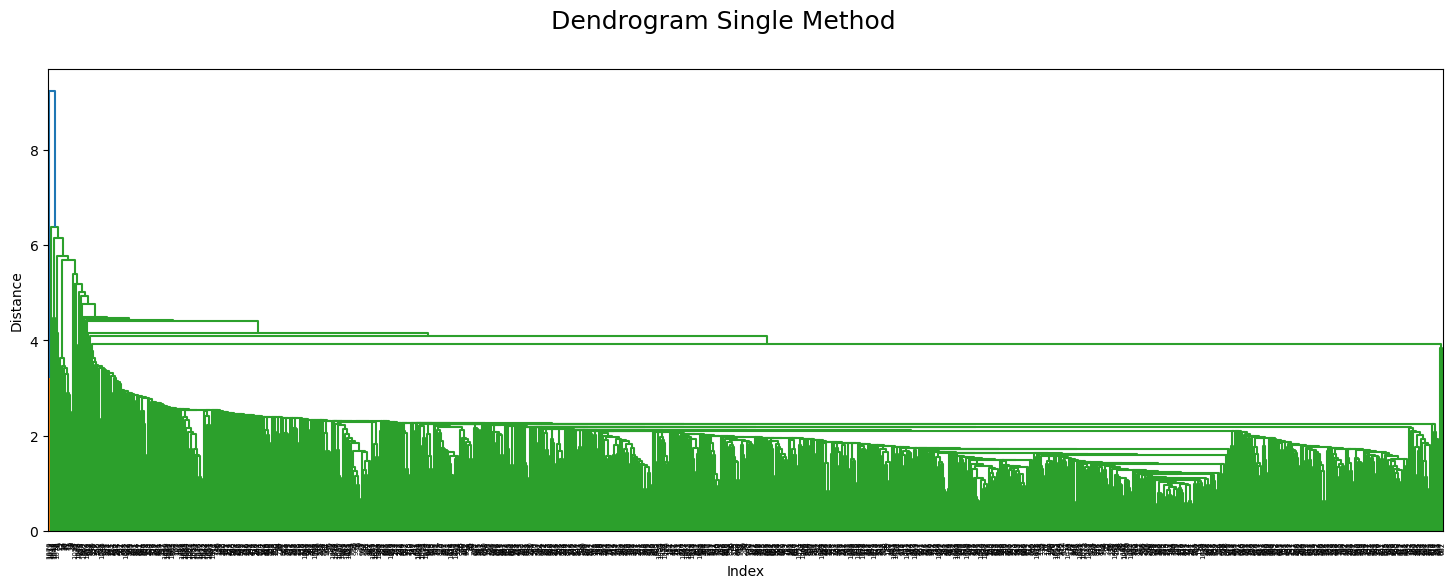

In [16]:
plt.figure(figsize=(18,6))
distance_single = linkage(df_1989.loc[:,['temp_max', 'temp_min', 'precipitation', 'sunshine', 'cloud_cover', 'humidity', 'pressure', 'snow_depth', 'wind_speed']],method="single")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

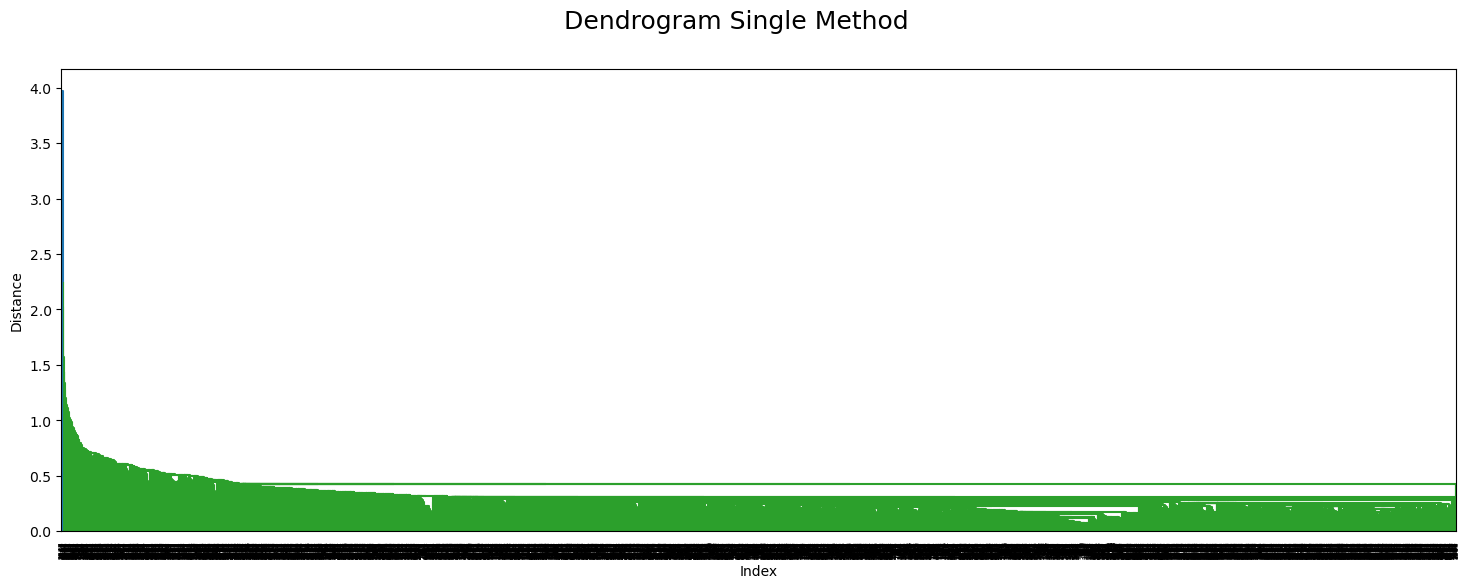

In [91]:
plt.figure(figsize=(18,6))
distance_single = linkage(features_scaled.loc[:, feature_cols],method="single")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

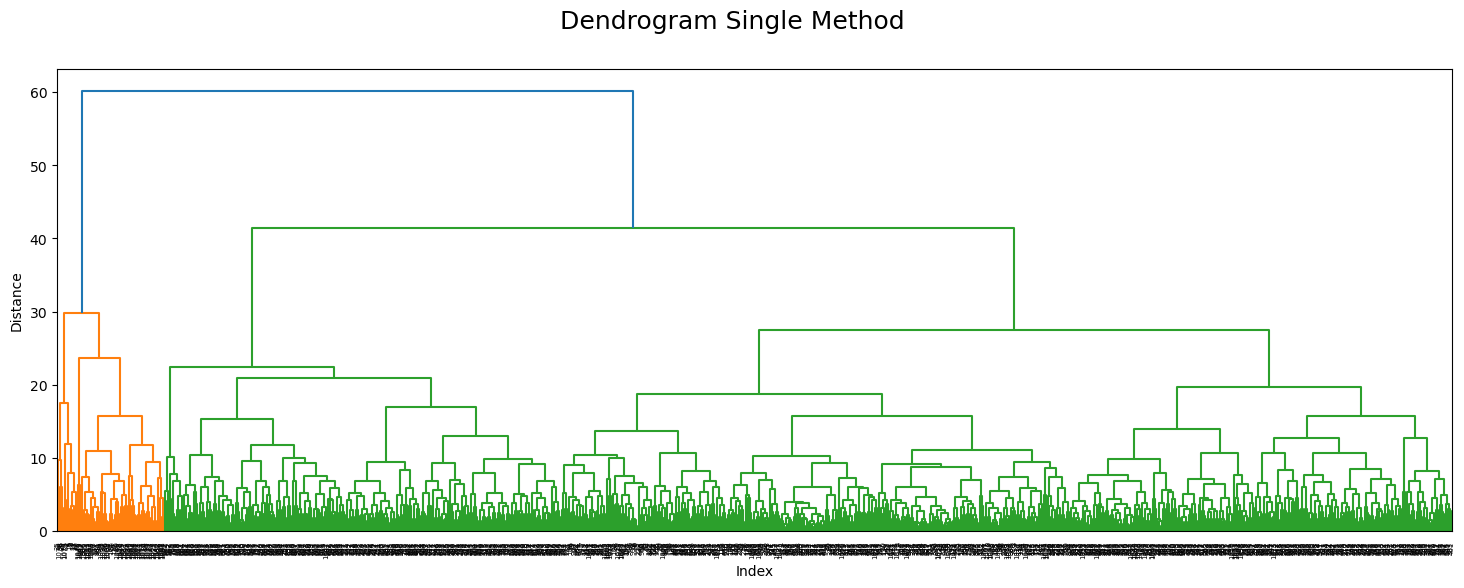

In [17]:
plt.figure(figsize=(18,6))
distance_single = linkage(df_1989.loc[:,['temp_max', 'temp_min', 'precipitation', 'sunshine', 'cloud_cover', 'humidity', 'pressure', 'snow_depth', 'wind_speed']],method="complete")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

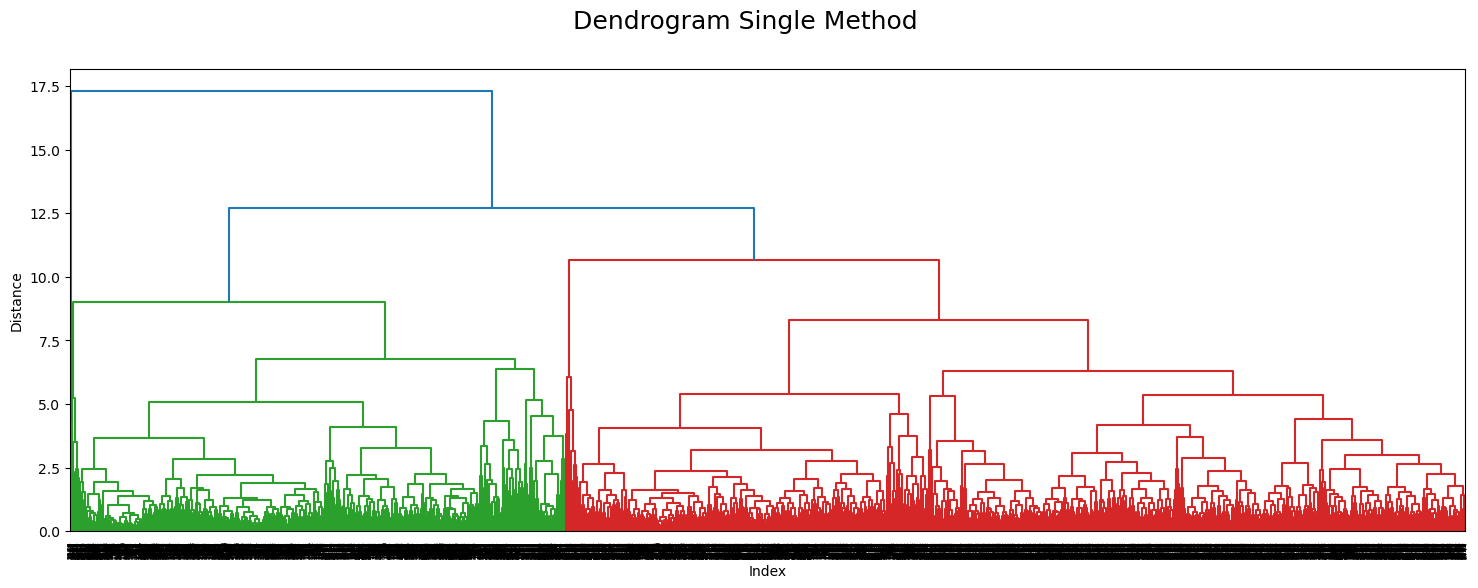

In [90]:
plt.figure(figsize=(18,6))
distance_single = linkage(features_scaled.loc[:, feature_cols],method="complete")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

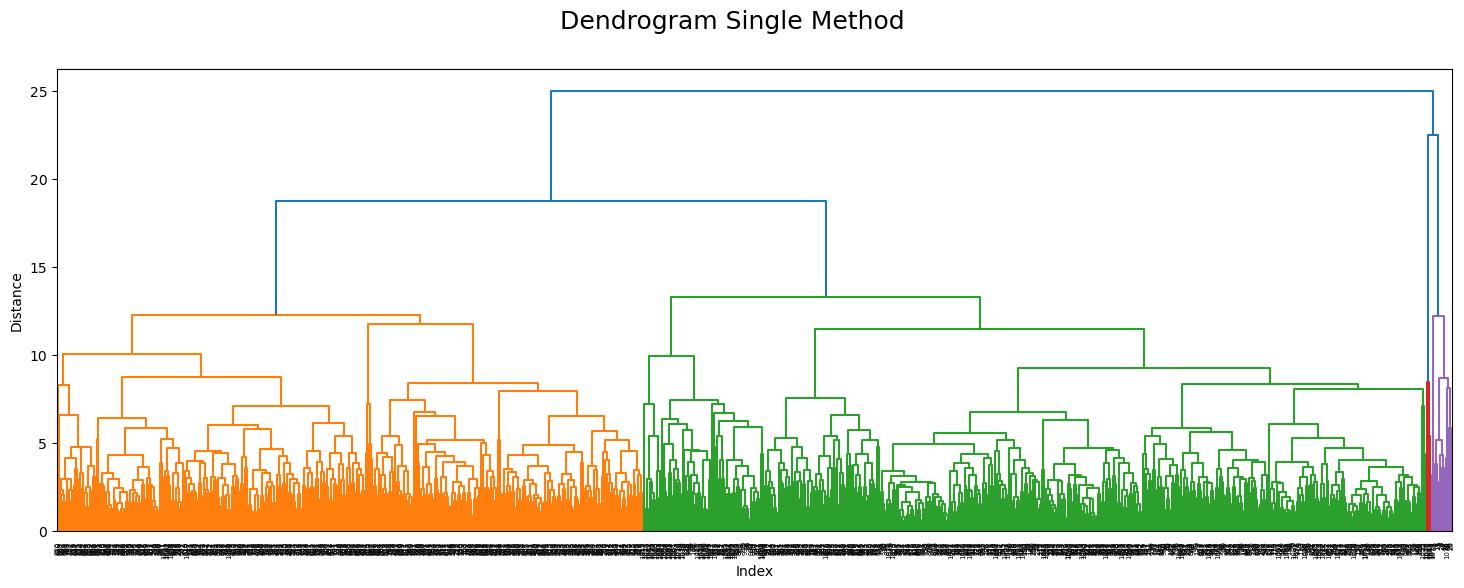

In [18]:
plt.figure(figsize=(18,6))
distance_single = linkage(df_1989.loc[:,['temp_max', 'temp_min', 'precipitation', 'sunshine', 'cloud_cover', 'humidity', 'pressure', 'snow_depth', 'wind_speed']],method="average")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

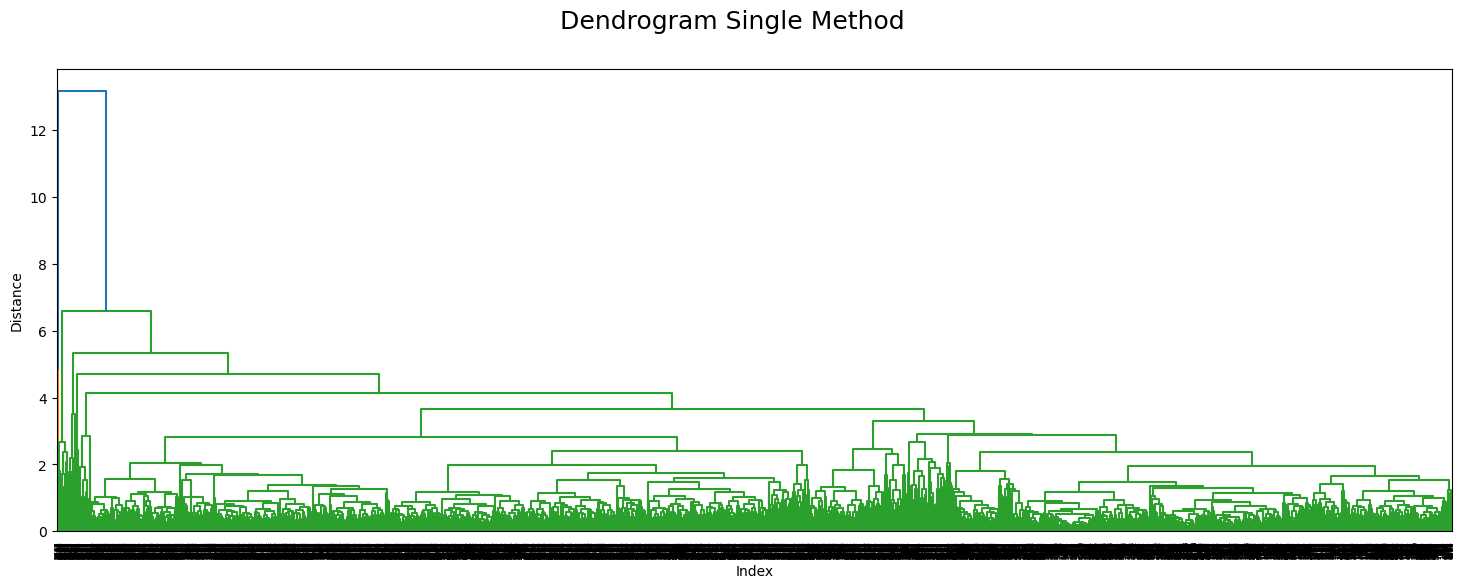

In [89]:
plt.figure(figsize=(18,6))
distance_single = linkage(features_scaled.loc[:, feature_cols],method="average")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

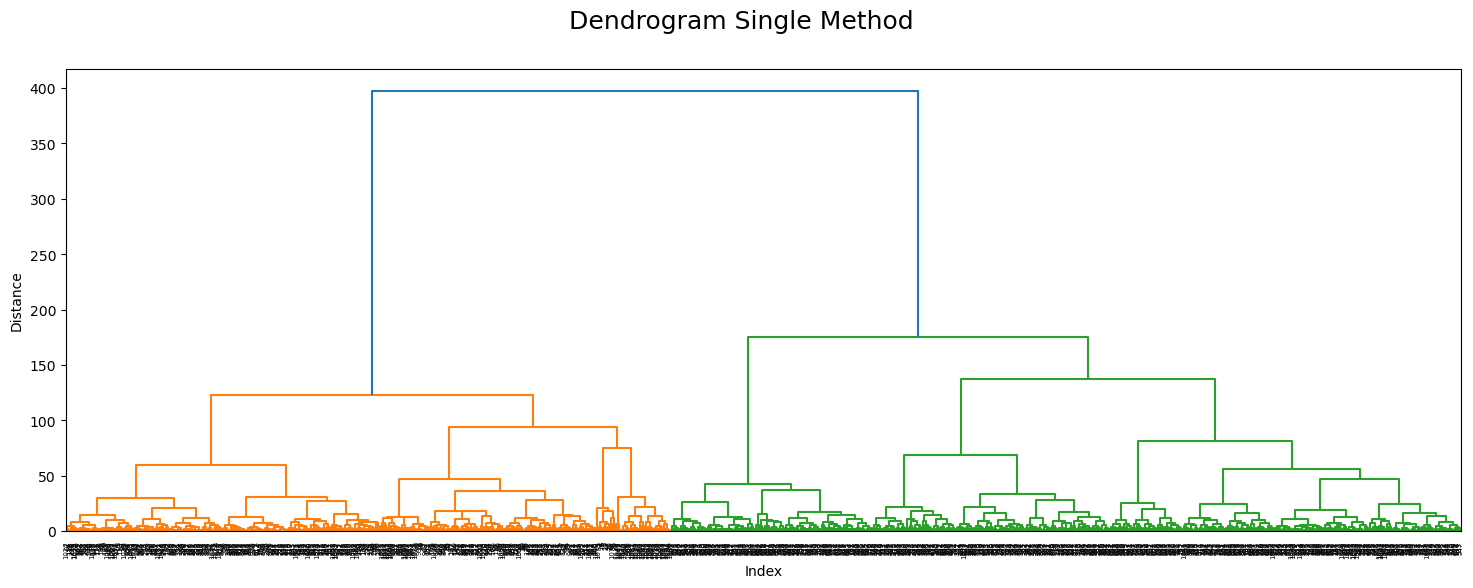

In [19]:
plt.figure(figsize=(18,6))
distance_single = linkage(df_1989.loc[:,['temp_max', 'temp_min', 'precipitation', 'sunshine', 'cloud_cover', 'humidity', 'pressure', 'snow_depth', 'wind_speed']],method="ward")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

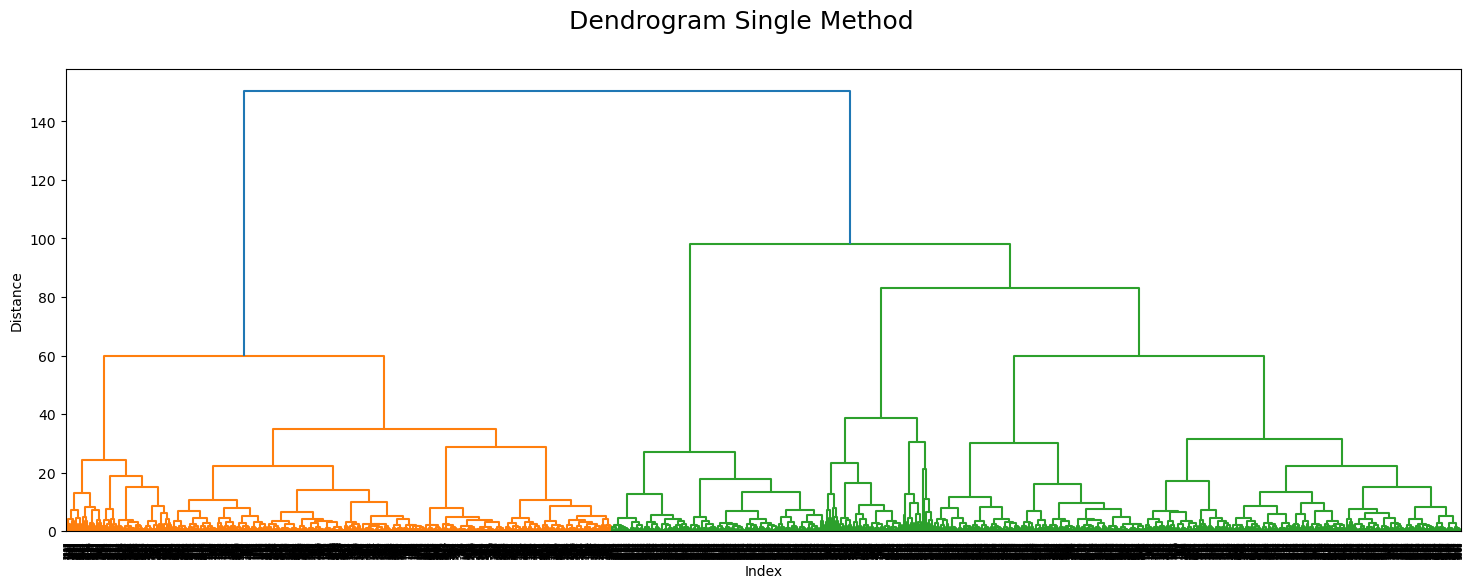

In [38]:
plt.figure(figsize=(18,6))
distance_single = linkage(features_scaled.loc[:, feature_cols],method="ward")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

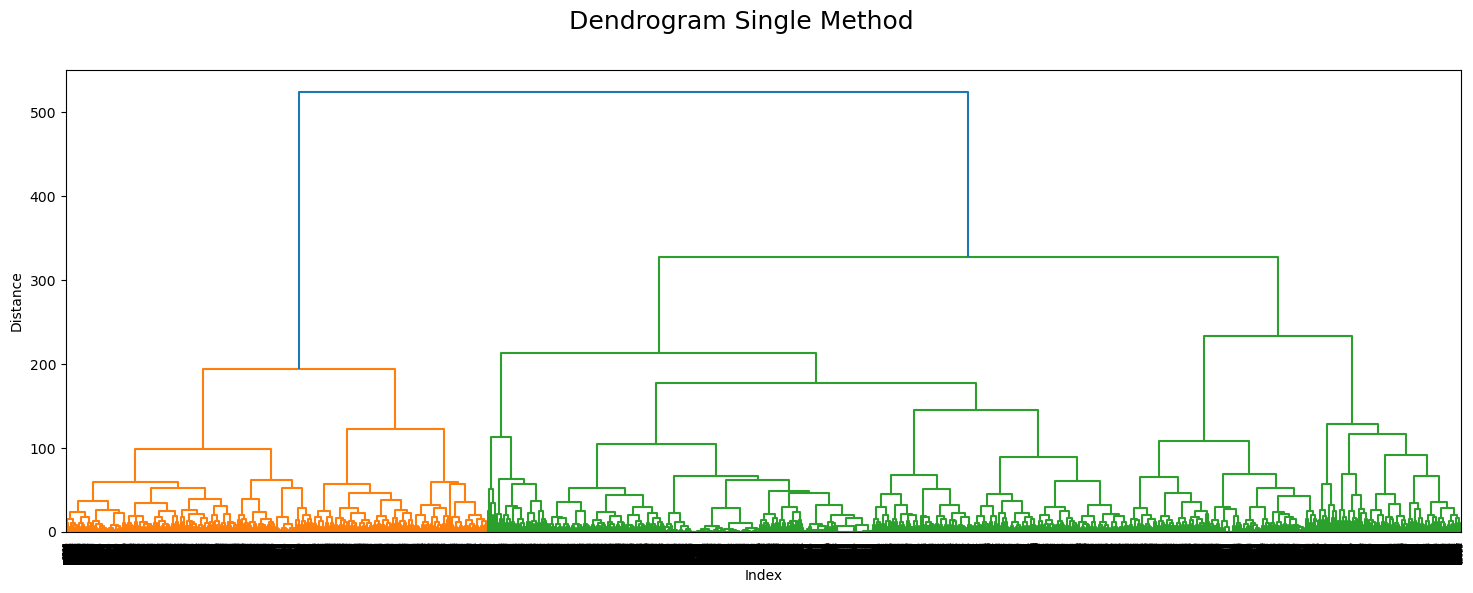

In [32]:
plt.figure(figsize=(18,6))
distance_single = linkage(noughts_scaled.loc[:, feature_cols],method="ward")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

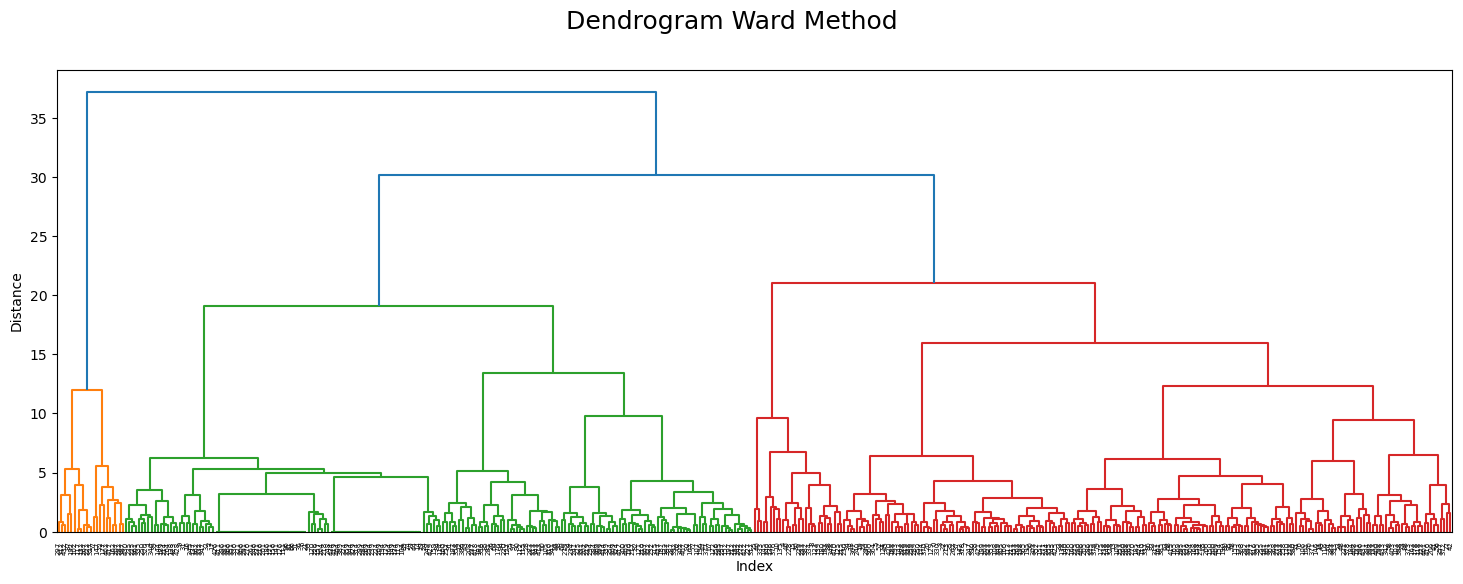

In [63]:
plt.figure(figsize=(18,6))
distance_single = linkage(feb20_scaled.loc[:, feature_cols],method="ward")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()

In [33]:
test = noughts_scaled.reset_index()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54795 entries, 0 to 54794
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   city              54795 non-null  object        
 1   DATE              54795 non-null  datetime64[ns]
 2   cloud_cover       54795 non-null  float64       
 3   global_radiation  54795 non-null  float64       
 4   humidity          54795 non-null  float64       
 5   precipitation     54795 non-null  float64       
 6   pressure          54795 non-null  float64       
 7   sunshine          54795 non-null  float64       
 8   temp_max          54795 non-null  float64       
 9   temp_mean         54795 non-null  float64       
 10  temp_min          54795 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 4.6+ MB


In [112]:
test2 = noughts.drop(['MONTH'], axis=1)
test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54795 entries, 0 to 54794
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              54795 non-null  datetime64[ns]
 1   city              54795 non-null  object        
 2   global_radiation  54795 non-null  float64       
 3   precipitation     54795 non-null  float64       
 4   sunshine          54795 non-null  float64       
 5   temp_max          54795 non-null  float64       
 6   temp_mean         54795 non-null  float64       
 7   temp_min          54795 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 3.3+ MB


In [35]:
# Get cluster assignments for noughts
n_clusters = 2
cluster_labels = fcluster(distance_single, n_clusters, criterion='maxclust')

# Create results DataFrame
results = pd.DataFrame({
    'city': noughts_scaled.index.get_level_values('city').tolist(),
    'cluster': cluster_labels
})

# Show what's in each cluster
print("Cluster Membership:")
for cluster_id in sorted(results['cluster'].unique()):
    cities = np.sort(results[results['cluster'] == cluster_id]['city'].unique().tolist())
    print(f"Cluster {cluster_id}: {cities}")

Cluster Membership:
Cluster 1: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM']
Cluster 2: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM' 'VALENTIA']


In [96]:
# Get cluster assignments for feb 2020
n_clusters = 3
cluster_labels = fcluster(distance_single, n_clusters, criterion='maxclust')

# Create results DataFrame
results = pd.DataFrame({
    'city': feb20_scaled.index.get_level_values('city').tolist(),
    'cluster': cluster_labels
})

# Show what's in each cluster
print("Cluster Membership:")
for cluster_id in sorted(results['cluster'].unique()):
    cities = np.sort(results[results['cluster'] == cluster_id]['city'].unique().tolist())
    print(f"Cluster {cluster_id}: {cities}")

Cluster Membership:
Cluster 1: ['SONNBLICK']
Cluster 2: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM' 'VALENTIA']
Cluster 3: ['BASEL' 'BELGRADE' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'LJUBLJANA'
 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK' 'STOCKHOLM']


In [44]:
merged00 = merged[(merged['DATE'].dt.year>2010) & (climate_df['DATE'].dt.year<=2020)]

In [40]:
# Get cluster assignments for noughts
n_clusters = 2
cluster_labels = fcluster(distance_single, n_clusters, criterion='maxclust')

# Create results DataFrame for noughts
results = pd.DataFrame({
    'city': noughts_scaled.index.get_level_values('city'),
    'DATE': noughts_scaled.index.get_level_values('DATE'),
    'cluster': cluster_labels
})

# Show what's in each cluster
print("Cluster Membership:")
for cluster_id in sorted(results['cluster'].unique()):
    cities = np.sort(results[results['cluster'] == cluster_id]['city'].unique().tolist())
    print(f"Cluster {cluster_id}: {cities}")

# Add all features
feature_columns = noughts_scaled.columns.tolist()
for col in feature_columns:
    results[col] = noughts[col].values

In [56]:
# Get cluster assignments for noughts
n_clusters = 8
cluster_labels = fcluster(distance_single, n_clusters, criterion='maxclust')

# Create results DataFrame for noughts
results = pd.DataFrame({
    'city': noughts_scaled.index.get_level_values('city'),
    'DATE': noughts_scaled.index.get_level_values('DATE'),
    'cluster': cluster_labels
})

# Show what's in each cluster
print("Cluster Membership:")
for cluster_id in sorted(results['cluster'].unique()):
    cities = np.sort(results[results['cluster'] == cluster_id]['city'].unique().tolist())
    print(f"Cluster {cluster_id}: {cities}")

# Add all features
feature_columns = noughts_scaled.columns.tolist()
for col in feature_columns:
    results[col] = noughts[col].values

Cluster Membership:
Cluster 1: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'STOCKHOLM']
Cluster 2: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM']
Cluster 3: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM']
Cluster 4: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM' 'VALENTIA']
Cluster 5: ['BASEL' 'BELGRADE' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL' 'LJUBLJANA'
 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK' 'STOCKHOLM']
Cluster 6: ['BASEL' 'BELGRADE' 'BUDAPEST' 'DEBILT' 'DUSSELDORF' 'HEATHROW' 'KASSEL'
 'LJUBLJANA' 'MAASTRICHT' 'MADRID' 'MUNCHENB' 'OSLO' 'SONNBLICK'
 'STOCKHOLM']
Cluster 7: ['BAS

In [79]:
# Get cluster assignments for noughts
n_clusters = 8
cluster_labels = fcluster(noughts_ward, n_clusters, criterion='maxclust')

# Create results DataFrame for noughts
results = pd.DataFrame({
    'city': noughts_scaled.index.get_level_values('city'),
    'DATE': noughts_scaled.index.get_level_values('DATE'),
    'cluster': cluster_labels
})

# Add all features
feature_columns = noughts_scaled.columns.tolist()
for col in feature_columns:
    results[col] = noughts[col].values

In [97]:
# Create results DataFrame
results = pd.DataFrame({
    'city': feb20_scaled.index.get_level_values('city'),
    'date': feb20_scaled.index.get_level_values('DATE'),
    'cluster': cluster_labels
})

# Add all features
feature_columns = feb20_scaled.columns.tolist()
for col in feature_columns:
    results[col] = feb20[col].values

In [50]:
# noughts
results['cluster'].value_counts().sort_index()

cluster
1    16595
2    25198
3    13002
Name: count, dtype: int64

In [36]:
# noughts
results['cluster'].value_counts().sort_index()

cluster
1    16595
2    38200
Name: count, dtype: int64

In [57]:
# noughts
results['cluster'].value_counts().sort_index()

cluster
1     9697
2     6898
3     2398
4    12691
5     3941
6     6168
7     7403
8     5599
Name: count, dtype: int64

In [101]:
# feb 2020
results['cluster'].value_counts().sort_values()

cluster
1     21
2    196
3    218
Name: count, dtype: int64

In [98]:
# feb 2020
results.groupby('cluster')[feature_cols].mean()

,global_radiation,precipitation,sunshine,temp_max,temp_mean,temp_min
cluster,,,,,,
1,1.122857,0.645714,4.600000,-8.314286,-11.680952,-15.000000
2,1.170000,0.118520,5.679592,12.200000,7.951531,4.088265
3,0.587202,0.402706,1.821101,9.196330,6.078440,2.944495


In [41]:
# noughts
results_pleas = results.merge(ans_long, on=['DATE', 'city'], how='left')
results_pleas

,city,DATE,cluster,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,BASEL,2011-01-01,2,8.0,0.13,0.97,0.00,1.0232,0.0,0.3,-0.2,-0.8,0
1,BELGRADE,2011-01-01,2,4.0,0.64,0.92,0.00,1.0227,3.1,-2.3,-5.5,-8.6,0
2,BUDAPEST,2011-01-01,2,4.0,0.38,0.67,0.00,1.0170,1.4,0.1,-1.7,-4.8,0
3,DEBILT,2011-01-01,2,6.0,0.22,0.93,0.06,1.0211,1.2,5.9,3.5,-0.3,0
4,DUSSELDORF,2011-01-01,2,6.0,0.12,0.95,0.07,1.0212,0.0,2.9,1.3,-4.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54790,MUNCHENB,2020-12-31,2,4.0,0.70,0.69,0.00,1.0108,7.1,5.1,1.3,-1.9,0
54791,OSLO,2020-12-31,2,8.0,0.10,0.87,0.00,1.0013,0.0,1.5,0.2,-0.2,0
54792,SONNBLICK,2020-12-31,2,3.0,0.57,0.78,0.00,1.0250,5.3,-12.8,-14.4,-15.9,0
54793,STOCKHOLM,2020-12-31,2,5.0,0.05,0.87,0.08,1.0034,0.0,4.5,3.7,2.5,0


In [51]:
# noughts
results_pleas3 = results.merge(ans_long, on=['DATE', 'city'], how='left')
results_pleas3

,city,DATE,cluster,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,BASEL,2011-01-01,2,8.0,0.13,0.97,0.00,1.0232,0.0,0.3,-0.2,-0.8,0
1,BELGRADE,2011-01-01,3,4.0,0.64,0.92,0.00,1.0227,3.1,-2.3,-5.5,-8.6,0
2,BUDAPEST,2011-01-01,2,4.0,0.38,0.67,0.00,1.0170,1.4,0.1,-1.7,-4.8,0
3,DEBILT,2011-01-01,2,6.0,0.22,0.93,0.06,1.0211,1.2,5.9,3.5,-0.3,0
4,DUSSELDORF,2011-01-01,2,6.0,0.12,0.95,0.07,1.0212,0.0,2.9,1.3,-4.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54790,MUNCHENB,2020-12-31,3,4.0,0.70,0.69,0.00,1.0108,7.1,5.1,1.3,-1.9,0
54791,OSLO,2020-12-31,2,8.0,0.10,0.87,0.00,1.0013,0.0,1.5,0.2,-0.2,0
54792,SONNBLICK,2020-12-31,3,3.0,0.57,0.78,0.00,1.0250,5.3,-12.8,-14.4,-15.9,0
54793,STOCKHOLM,2020-12-31,2,5.0,0.05,0.87,0.08,1.0034,0.0,4.5,3.7,2.5,0


In [58]:
# noughts
results_pleas8 = results.merge(ans_long, on=['DATE', 'city'], how='left')
results_pleas8

,city,DATE,cluster,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,BASEL,2011-01-01,6,8.0,0.13,0.97,0.00,1.0232,0.0,0.3,-0.2,-0.8,0
1,BELGRADE,2011-01-01,8,4.0,0.64,0.92,0.00,1.0227,3.1,-2.3,-5.5,-8.6,0
2,BUDAPEST,2011-01-01,6,4.0,0.38,0.67,0.00,1.0170,1.4,0.1,-1.7,-4.8,0
3,DEBILT,2011-01-01,6,6.0,0.22,0.93,0.06,1.0211,1.2,5.9,3.5,-0.3,0
4,DUSSELDORF,2011-01-01,6,6.0,0.12,0.95,0.07,1.0212,0.0,2.9,1.3,-4.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54790,MUNCHENB,2020-12-31,7,4.0,0.70,0.69,0.00,1.0108,7.1,5.1,1.3,-1.9,0
54791,OSLO,2020-12-31,6,8.0,0.10,0.87,0.00,1.0013,0.0,1.5,0.2,-0.2,0
54792,SONNBLICK,2020-12-31,8,3.0,0.57,0.78,0.00,1.0250,5.3,-12.8,-14.4,-15.9,0
54793,STOCKHOLM,2020-12-31,5,5.0,0.05,0.87,0.08,1.0034,0.0,4.5,3.7,2.5,0


In [47]:
group = results_pleas.drop(['DATE','city'], axis=1)

In [52]:
group3 = results_pleas3.drop(['DATE','city'], axis=1)

In [61]:
group8 = results_pleas8.drop(['DATE','city'], axis=1)

In [48]:
# noughts
group.groupby('cluster').mean()

,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
cluster,,,,,,,,,,
1,3.778186,2.212862,0.624991,0.071456,1.016302,8.912829,24.438259,18.619422,12.894269,0.663935
2,5.464791,0.961953,0.791519,0.309817,1.017047,3.524319,10.169547,6.767605,3.632118,0.041021


In [53]:
# noughts
group3.groupby('cluster').mean()

,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
cluster,,,,,,,,,,
1,3.778186,2.212862,0.624991,0.071456,1.016302,8.912829,24.438259,18.619422,12.894269,0.663935
2,6.369394,0.785406,0.816322,0.383866,1.013177,2.177046,11.847262,8.745559,5.885169,0.021549
3,3.711660,1.304101,0.743451,0.166309,1.024546,6.135348,6.918120,2.934310,-0.734318,0.078757


In [62]:
# noughts
group8.groupby('cluster').mean()

,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
cluster,,,,,,,,,,
1,4.672579,1.800579,0.680785,0.115970,1.015492,6.852862,23.582737,18.137991,13.173992,0.546664
2,2.520876,2.792437,0.546557,0.008879,1.017440,11.808669,25.640925,19.296202,12.501044,0.828791
3,6.791493,0.986685,0.825780,1.820200,1.009926,2.416472,16.160008,12.372852,9.484654,0.000000
4,6.061382,1.038582,0.795689,0.256004,1.013684,2.937113,14.730707,11.285832,8.151383,0.041762
5,6.561533,0.379645,0.853656,0.368734,1.002168,1.148211,8.103223,5.597742,3.121467,0.000507
6,6.716278,0.445490,0.831245,0.098199,1.020434,1.177448,6.629929,4.119861,1.588748,0.001783
7,2.852627,1.402800,0.674331,0.039235,1.020313,7.347278,12.145144,7.263488,2.811738,0.138322
8,4.847473,1.173601,0.834842,0.334326,1.030144,4.532934,0.006948,-2.789730,-5.422915,0.000000


In [58]:
# noughts
results_pleas.groupby('cluster')[['precipitation','sunshine', 'temp_max', 'pleasant_weather']].mean()

,precipitation,sunshine,temp_max,pleasant_weather
cluster,,,,
1,0.254896,2.603155,3.976225,0.000000
2,0.015567,11.318212,26.072085,0.833996
3,0.301147,4.557395,16.572792,0.159317


In [62]:
# noughts
results_pleas2.groupby('cluster')[['precipitation','sunshine', 'temp_max', 'pleasant_weather']].mean()

,precipitation,sunshine,temp_max,pleasant_weather
cluster,,,,
1,0.254896,2.603155,3.976225,0.000000
2,0.230341,6.233651,18.928017,0.326595


In [82]:
# noughts
results_pleas4.groupby('cluster')[['precipitation','sunshine', 'temp_max', 'pleasant_weather']].mean()

,precipitation,sunshine,temp_max,pleasant_weather
cluster,,,,
1,0.144094,4.750543,0.442695,0.000000
2,0.111531,1.253393,6.607231,0.000000
3,1.319001,0.554966,5.501884,0.000000
4,0.015567,11.318212,26.072085,0.833996
5,1.676462,3.845870,19.733882,0.000000
6,0.108263,4.952832,21.578120,0.467803
7,0.311098,1.918845,14.347817,0.014983
8,0.081124,6.459838,13.168235,0.052042


In [42]:
df89_scaled.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5475 entries, ('BASEL', Timestamp('1989-01-01 00:00:00')) to ('VALENTIA', Timestamp('1989-12-31 00:00:00'))
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cloud_cover       5475 non-null   float64
 1   global_radiation  5475 non-null   float64
 2   humidity          5475 non-null   float64
 3   precipitation     5475 non-null   float64
 4   pressure          5475 non-null   float64
 5   sunshine          5475 non-null   float64
 6   temp_max          5475 non-null   float64
 7   temp_mean         5475 non-null   float64
 8   temp_min          5475 non-null   float64
dtypes: float64(9)
memory usage: 412.7+ KB


In [46]:
# PCA for dimensionality reduction
pca = PCA(n_components=6)
pca_features = pca.fit_transform(df89_scaled)

In [47]:
dfPCA = pd.DataFrame(pca_features)

<Axes: >

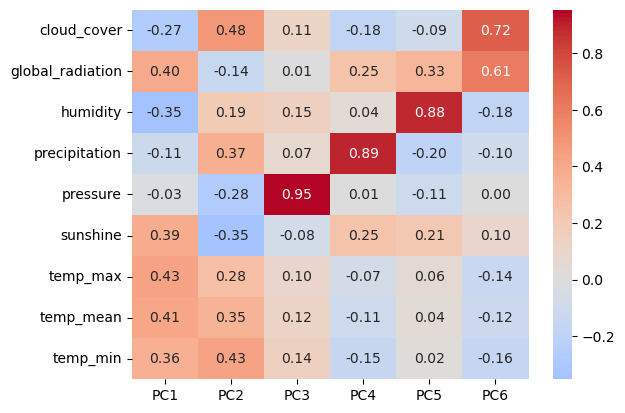

In [48]:
# Loadings Heatmap
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(6)],
    index=noughts_scaled.columns
)
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f')

In [59]:
full.to_csv(os.path.join(path, 'dendro_pca.csv'))

In [38]:
dfPCA

,0,1,2
0,-3.463095,0.195649,-0.759133
1,-3.094403,2.015919,-0.172901
2,-2.210088,1.496996,-0.579185
3,-2.496280,0.240879,-0.591454
4,-3.141093,0.485066,-0.580075
...,...,...,...
54790,-1.060736,1.220896,-0.421304
54791,-3.053616,-0.862290,-1.250750
54792,-3.730100,3.754133,0.155640
54793,-2.263710,-0.655611,-1.024384


In [ ]:
plt.figure(figsize=(18,6))
pca_ward = linkage(dfPCA,method="ward")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()

In [51]:
dfPCA

,0,1,2,3,4,5
0,-2.796792,-0.257146,0.693373,-0.813215,-0.401531,0.467115
1,-2.092447,-0.429244,0.454956,-0.670722,-0.346595,-0.019265
2,-1.226799,-1.189017,0.197759,-0.290749,-0.466850,-0.349448
3,-1.955402,0.612444,1.020804,-1.081545,-0.163734,0.076239
4,-2.237933,0.718738,1.088891,-0.938305,0.309337,-0.011698
...,...,...,...,...,...,...
5470,-2.649850,-2.333712,-0.407116,0.293361,0.634659,-0.336142
5471,-3.442098,-1.944116,-0.214715,-0.292420,-0.959172,0.047361
5472,-2.213401,-3.827276,-0.490106,0.871035,0.343649,-0.671983
5473,-2.744250,-0.369760,0.215502,-0.837347,-0.972491,0.554301


In [57]:
df_1989

,DATE,MONTH,city,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,1989-01-01,1,BASEL,8.0,0.16,0.83,0.00,1.0379,0.0,2.2,0.7,-0.1,0
1,1989-01-01,1,BELGRADE,6.0,0.40,0.80,0.00,1.0328,0.3,4.7,2.4,1.5,0
2,1989-01-01,1,BUDAPEST,4.0,0.54,0.72,0.00,1.0318,4.3,5.3,3.0,1.5,0
3,1989-01-01,1,DEBILT,8.0,0.11,0.86,0.00,1.0384,0.0,8.6,7.3,5.5,0
4,1989-01-01,1,DUSSELDORF,8.0,0.12,0.95,0.06,1.0382,0.0,7.5,6.5,5.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5470,1989-12-31,12,MUNCHENB,3.0,0.62,0.91,0.00,1.0237,5.4,-1.0,-6.0,-8.0,0
5471,1989-12-31,12,OSLO,5.0,0.04,0.73,0.00,1.0301,0.0,-3.1,-7.2,-9.7,0
5472,1989-12-31,12,SONNBLICK,0.0,0.90,0.81,0.00,1.0322,8.6,-6.9,-8.4,-9.9,0
5473,1989-12-31,12,STOCKHOLM,8.0,0.05,0.73,0.00,1.0291,0.0,0.8,0.0,-0.7,0


In [58]:
full = pd.concat([df_1989, dfPCA], axis=1)
full

,DATE,MONTH,city,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather,0,1,2,3,4,5
0,1989-01-01,1,BASEL,8.0,0.16,0.83,0.00,1.0379,0.0,2.2,0.7,-0.1,0,-2.796792,-0.257146,0.693373,-0.813215,-0.401531,0.467115
1,1989-01-01,1,BELGRADE,6.0,0.40,0.80,0.00,1.0328,0.3,4.7,2.4,1.5,0,-2.092447,-0.429244,0.454956,-0.670722,-0.346595,-0.019265
2,1989-01-01,1,BUDAPEST,4.0,0.54,0.72,0.00,1.0318,4.3,5.3,3.0,1.5,0,-1.226799,-1.189017,0.197759,-0.290749,-0.466850,-0.349448
3,1989-01-01,1,DEBILT,8.0,0.11,0.86,0.00,1.0384,0.0,8.6,7.3,5.5,0,-1.955402,0.612444,1.020804,-1.081545,-0.163734,0.076239
4,1989-01-01,1,DUSSELDORF,8.0,0.12,0.95,0.06,1.0382,0.0,7.5,6.5,5.9,0,-2.237933,0.718738,1.088891,-0.938305,0.309337,-0.011698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5470,1989-12-31,12,MUNCHENB,3.0,0.62,0.91,0.00,1.0237,5.4,-1.0,-6.0,-8.0,0,-2.649850,-2.333712,-0.407116,0.293361,0.634659,-0.336142
5471,1989-12-31,12,OSLO,5.0,0.04,0.73,0.00,1.0301,0.0,-3.1,-7.2,-9.7,0,-3.442098,-1.944116,-0.214715,-0.292420,-0.959172,0.047361
5472,1989-12-31,12,SONNBLICK,0.0,0.90,0.81,0.00,1.0322,8.6,-6.9,-8.4,-9.9,0,-2.213401,-3.827276,-0.490106,0.871035,0.343649,-0.671983
5473,1989-12-31,12,STOCKHOLM,8.0,0.05,0.73,0.00,1.0291,0.0,0.8,0.0,-0.7,0,-2.744250,-0.369760,0.215502,-0.837347,-0.972491,0.554301
